In [9]:
# hybrid_ensemble.py
# Hybrid Ensemble (ResNet50 + EfficientNetB0) for Brain Stroke Detection
# Generates threshold tuning + weighted ensemble + confusion matrix + ROC curve

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess_input


# -----------------------------
# CONFIG
# -----------------------------
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

TEST_DIR = os.path.join(PROJECT_DIR, "dataset", "test")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")

IMG_SIZE = 224
BATCH_SIZE = 8

RESNET_MODEL_PATH = os.path.join(MODELS_DIR, "resnet50_best.h5")
EFF_MODEL_PATH    = os.path.join(MODELS_DIR, "efficientnetb0_best.h5")


os.makedirs(OUTPUT_DIR, exist_ok=True)


# -----------------------------
# Preprocessing
# -----------------------------
def resnet_preprocessing(img):
    """Your CT preprocessing used for ResNet: grayscale + CLAHE + blur + normalize [0..1] + 3ch."""
    img = img.astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    gray = gray.astype(np.float32) / 255.0
    out = np.stack([gray, gray, gray], axis=-1)
    return out


def efficientnet_preprocessing(img):
    """Your CT preprocessing used for EfficientNet: grayscale + CLAHE + blur + EfficientNet preprocess_input."""
    img = img.astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    x = np.stack([gray, gray, gray], axis=-1).astype(np.float32)
    x = eff_preprocess_input(x)
    return x


# -----------------------------
# Utility: metrics
# -----------------------------
def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    return acc, prec, rec, f1, roc_auc, fpr, tpr


def save_confusion_matrix(y_true, y_pred, title, out_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Normal", "Stroke"],
        yticklabels=["Normal", "Stroke"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()
    return cm


def save_roc_curve(fpr, tpr, roc_auc, title, out_path):
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()


# -----------------------------
# Main
# -----------------------------
def main():
    print("✅ Loading models...")
    if not os.path.exists(RESNET_MODEL_PATH):
        raise FileNotFoundError(f"ResNet model not found: {RESNET_MODEL_PATH}")
    if not os.path.exists(EFF_MODEL_PATH):
        raise FileNotFoundError(f"EfficientNet model not found: {EFF_MODEL_PATH}")

    resnet_model = load_model(RESNET_MODEL_PATH)
    eff_model = load_model(EFF_MODEL_PATH)

    print("✅ Creating test generators...")
    resnet_test_gen = ImageDataGenerator(preprocessing_function=resnet_preprocessing)
    eff_test_gen = ImageDataGenerator(preprocessing_function=efficientnet_preprocessing)

    resnet_test_data = resnet_test_gen.flow_from_directory(
        TEST_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    eff_test_data = eff_test_gen.flow_from_directory(
        TEST_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    # Ensure identical file order
    if resnet_test_data.filenames != eff_test_data.filenames:
        raise RuntimeError("❌ Test generators are not aligned (different file order). Make sure shuffle=False in both.")

    y_true = resnet_test_data.classes
    print("Class indices:", resnet_test_data.class_indices)
    print("Total test samples:", len(y_true))

    print("\n✅ Predicting probabilities...")
    resnet_test_data.reset()
    eff_test_data.reset()

    p_resnet = resnet_model.predict(resnet_test_data, verbose=1).ravel()
    p_eff = eff_model.predict(eff_test_data, verbose=1).ravel()

    # Default 50-50 average hybrid
    p_hybrid = (p_resnet + p_eff) / 2.0

    # -----------------------------------
    # Threshold tuning (equal weights)
    # -----------------------------------
    print("\n=== Threshold Tuning (w=0.5 average) ===")
    thresholds = [i / 100 for i in range(30, 81, 5)]  # 0.30..0.80 step 0.05
    rows = []
    for thr in thresholds:
        y_pred = (p_hybrid >= thr).astype(int)
        acc, prec, rec, f1, roc_auc, _, _ = compute_metrics(y_true, y_pred, p_hybrid)
        rows.append((thr, acc, prec, rec, f1))
    print("thr | acc | prec | recall | f1")
    for thr, acc, prec, rec, f1 in rows:
        print(f"{thr:.2f} | {acc:.3f} | {prec:.3f} | {rec:.3f} | {f1:.3f}")

    # -----------------------------------
    # Weighted ensemble search (optimize accuracy)
    # -----------------------------------
    print("\n=== Weighted Ensemble Search (optimize Accuracy) ===")
    weights = [i / 10 for i in range(0, 11)]           # 0.0..1.0
    thresholds = [i / 100 for i in range(30, 81, 2)]   # 0.30..0.80 step 0.02

    best_acc = -1
    best_row = None

    for w in weights:
        p_w = w * p_resnet + (1 - w) * p_eff
        for thr in thresholds:
            y_pred = (p_w >= thr).astype(int)
            acc, prec, rec, f1, roc_auc, _, _ = compute_metrics(y_true, y_pred, p_w)
            if acc > best_acc:
                best_acc = acc
                best_row = (w, thr, acc, prec, rec, f1, roc_auc)

    w_best, thr_best, acc_best, prec_best, rec_best, f1_best, auc_best = best_row
    print("✅ Best by Accuracy:")
    print(f"w={w_best:.2f}, thr={thr_best:.2f} | acc={acc_best:.3f} prec={prec_best:.3f} recall={rec_best:.3f} f1={f1_best:.3f} auc={auc_best:.3f}")

    # -----------------------------------
    # Final evaluation using best settings
    # -----------------------------------
    print("\n=== Final Hybrid Evaluation (best accuracy setting) ===")
    p_final = w_best * p_resnet + (1 - w_best) * p_eff
    y_pred_final = (p_final >= thr_best).astype(int)

    acc, prec, rec, f1, roc_auc, fpr, tpr = compute_metrics(y_true, y_pred_final, p_final)

    print("\nMetrics:")
    print({"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": roc_auc})

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_final, target_names=["Normal", "Stroke"], zero_division=0))

    # Save plots
    cm_path = os.path.join(OUTPUT_DIR, f"hybrid_confusion_matrix_w{w_best:.2f}_thr{thr_best:.2f}.png")
    roc_path = os.path.join(OUTPUT_DIR, f"hybrid_roc_w{w_best:.2f}_thr{thr_best:.2f}.png")

    cm = save_confusion_matrix(
        y_true, y_pred_final,
        title=f"Hybrid Confusion Matrix (w={w_best:.2f}, thr={thr_best:.2f})",
        out_path=cm_path
    )
    save_roc_curve(
        fpr, tpr, roc_auc,
        title=f"Hybrid ROC Curve (AUC={roc_auc:.3f})",
        out_path=roc_path
    )

    print("\n✅ Saved outputs:")
    print("Confusion Matrix image:", cm_path)
    print("ROC Curve image:", roc_path)
    print("Confusion Matrix values:\n", cm)


if __name__ == "__main__":
    main()


✅ Loading models...
✅ Creating test generators...
Found 437 images belonging to 2 classes.
Found 437 images belonging to 2 classes.
Class indices: {'Normal': 0, 'Stroke': 1}
Total test samples: 437

✅ Predicting probabilities...
55/55 [==============================] - 14s 222ms/step

=== Threshold Tuning (w=0.5 average) ===
thr | acc | prec | recall | f1
0.30 | 0.597 | 0.424 | 0.992 | 0.594
0.35 | 0.670 | 0.474 | 0.977 | 0.638
0.40 | 0.719 | 0.515 | 0.954 | 0.668
0.45 | 0.780 | 0.582 | 0.931 | 0.716
0.50 | 0.812 | 0.635 | 0.869 | 0.734
0.55 | 0.824 | 0.667 | 0.815 | 0.734
0.60 | 0.849 | 0.732 | 0.777 | 0.754
0.65 | 0.835 | 0.750 | 0.669 | 0.707
0.70 | 0.824 | 0.791 | 0.554 | 0.652
0.75 | 0.810 | 0.862 | 0.431 | 0.574
0.80 | 0.787 | 0.878 | 0.331 | 0.480

=== Weighted Ensemble Search (optimize Accuracy) ===
✅ Best by Accuracy:
w=0.50, thr=0.60 | acc=0.849 prec=0.732 recall=0.777 f1=0.754 auc=0.907

=== Final Hybrid Evaluation (best accuracy setting) ===

Metrics:
{'accuracy': 0.8489702

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

IMG_SIZE = 224
BATCH_SIZE = 8

TEST_DIR = os.path.join(PROJECT_DIR, "dataset", "test")

resnet_test_gen = ImageDataGenerator(preprocessing_function=resnet_preprocessing)

resnet_test_data = resnet_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Test samples:", resnet_test_data.samples)


Found 437 images belonging to 2 classes.
Test samples: 437


PROJECT_DIR: c:\Users\admin\Desktop\Brain_Stroke_Project
TEST_DIR: c:\Users\admin\Desktop\Brain_Stroke_Project\dataset\test
RESNET_MODEL_PATH exists: True
EFF_MODEL_PATH exists: True

✅ Models loaded successfully.
Found 437 images belonging to 2 classes.
Found 437 images belonging to 2 classes.

✅ Test generators aligned.
Total test samples: 437
Class indices: {'Normal': 0, 'Stroke': 1}
55/55 [==============================] - 19s 306ms/step

✅ Predictions done.
p_resnet shape: (437,)
p_eff shape: (437,)

=== Threshold Tuning (Equal Avg) ===
thr | acc | prec | recall | f1
0.30 | 0.597 | 0.424 | 0.992 | 0.594
0.35 | 0.670 | 0.474 | 0.977 | 0.638
0.40 | 0.719 | 0.515 | 0.954 | 0.668
0.45 | 0.780 | 0.582 | 0.931 | 0.716
0.50 | 0.812 | 0.635 | 0.869 | 0.734
0.55 | 0.824 | 0.667 | 0.815 | 0.734
0.60 | 0.849 | 0.732 | 0.777 | 0.754

=== Weighted Ensemble Search (Best Accuracy) ===
✅ Best by Accuracy:
w=0.50, thr=0.60 | acc=0.849 prec=0.732 recall=0.777 f1=0.754 auc=0.907

=== Final Weighted 

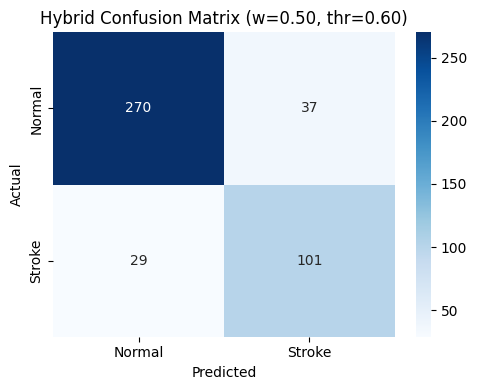

✅ Confusion matrix saved: c:\Users\admin\Desktop\Brain_Stroke_Project\outputs\hybrid_cm_w0.50_thr0.60.png
Confusion Matrix:
 [[270  37]
 [ 29 101]]


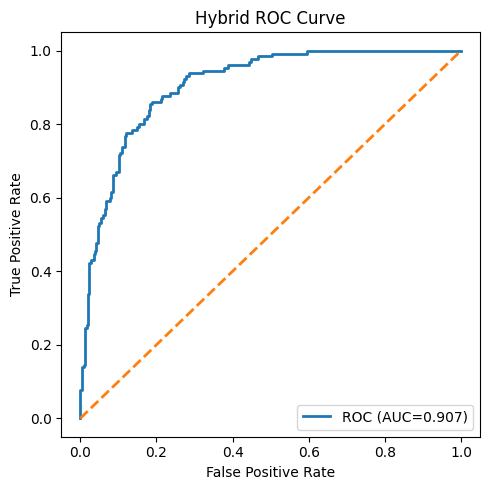

✅ ROC curve saved: c:\Users\admin\Desktop\Brain_Stroke_Project\outputs\hybrid_roc_w0.50_thr0.60.png

✅ Overall Hybrid Test Accuracy: 84.90%


In [11]:
# ==============================
# HYBRID ENSEMBLE (NOTEBOOK SAFE)
# ResNet50 + EfficientNetB0
# - Loads models
# - Creates aligned test generators
# - Predicts probabilities
# - Runs threshold tuning (equal weights)
# - Runs weighted ensemble search (best accuracy)
# - Prints final metrics + confusion matrix + ROC
# ==============================

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess_input


# -----------------------------
# 1) PROJECT PATH (Notebook-safe)
# -----------------------------
# If notebook is opened from Brain_Stroke_Project/notebooks,
# this makes PROJECT_DIR = Brain_Stroke_Project
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

TEST_DIR = os.path.join(PROJECT_DIR, "dataset", "test")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 8

RESNET_MODEL_PATH = os.path.join(MODELS_DIR, "resnet50_best.h5")
EFF_MODEL_PATH    = os.path.join(MODELS_DIR, "efficientnetb0_best.h5")

print("PROJECT_DIR:", PROJECT_DIR)
print("TEST_DIR:", TEST_DIR)
print("RESNET_MODEL_PATH exists:", os.path.exists(RESNET_MODEL_PATH))
print("EFF_MODEL_PATH exists:", os.path.exists(EFF_MODEL_PATH))


# -----------------------------
# 2) PREPROCESSING FUNCTIONS
# -----------------------------
def resnet_preprocessing(img):
    """CT preprocessing used for ResNet: grayscale + CLAHE + blur + normalize [0..1] + 3ch."""
    img = img.astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    gray = gray.astype(np.float32) / 255.0
    out = np.stack([gray, gray, gray], axis=-1)
    return out


def efficientnet_preprocessing(img):
    """CT preprocessing used for EfficientNet: grayscale + CLAHE + blur + EfficientNet preprocess_input."""
    img = img.astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    x = np.stack([gray, gray, gray], axis=-1).astype(np.float32)
    x = eff_preprocess_input(x)  # EfficientNet scaling
    return x


# -----------------------------
# 3) LOAD MODELS
# -----------------------------
if not os.path.exists(RESNET_MODEL_PATH):
    raise FileNotFoundError(f"ResNet model not found: {RESNET_MODEL_PATH}")
if not os.path.exists(EFF_MODEL_PATH):
    raise FileNotFoundError(f"EfficientNet model not found: {EFF_MODEL_PATH}")

resnet_model = load_model(RESNET_MODEL_PATH)
eff_model    = load_model(EFF_MODEL_PATH)

print("\n✅ Models loaded successfully.")


# -----------------------------
# 4) CREATE ALIGNED TEST GENERATORS
# -----------------------------
resnet_test_gen = ImageDataGenerator(preprocessing_function=resnet_preprocessing)
eff_test_gen    = ImageDataGenerator(preprocessing_function=efficientnet_preprocessing)

resnet_test_data = resnet_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

eff_test_data = eff_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Ensure same order
assert resnet_test_data.filenames == eff_test_data.filenames, "❌ Test generators not aligned. Ensure shuffle=False."

y_true = resnet_test_data.classes
print("\n✅ Test generators aligned.")
print("Total test samples:", len(y_true))
print("Class indices:", resnet_test_data.class_indices)


# -----------------------------
# 5) PREDICT PROBABILITIES
# -----------------------------
resnet_test_data.reset()
eff_test_data.reset()

p_resnet = resnet_model.predict(resnet_test_data, verbose=1).ravel()
p_eff    = eff_model.predict(eff_test_data, verbose=1).ravel()

print("\n✅ Predictions done.")
print("p_resnet shape:", p_resnet.shape)
print("p_eff shape:", p_eff.shape)


# -----------------------------
# 6) METRIC FUNCTION
# -----------------------------
def compute_all(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    return acc, prec, rec, f1, roc_auc, y_pred, fpr, tpr


# -----------------------------
# 7) THRESHOLD TUNING (Equal weights)
# -----------------------------
print("\n=== Threshold Tuning (Equal Avg) ===")
p_hybrid = (p_resnet + p_eff) / 2.0

thr_list = [0.30,0.35,0.40,0.45,0.50,0.55,0.60]
print("thr | acc | prec | recall | f1")

for thr in thr_list:
    acc, prec, rec, f1, roc_auc, _, _, _ = compute_all(y_true, p_hybrid, thr)
    print(f"{thr:.2f} | {acc:.3f} | {prec:.3f} | {rec:.3f} | {f1:.3f}")


# -----------------------------
# 8) WEIGHTED SEARCH (Best accuracy)
# -----------------------------
print("\n=== Weighted Ensemble Search (Best Accuracy) ===")
weights = [i/10 for i in range(0, 11)]          # 0.0..1.0
thresholds = [i/100 for i in range(30, 81, 2)]  # 0.30..0.80 step 0.02

best = None  # (acc, w, thr, prec, rec, f1, auc)

for w in weights:
    p_w = w*p_resnet + (1-w)*p_eff
    for thr in thresholds:
        acc, prec, rec, f1, roc_auc, _, _, _ = compute_all(y_true, p_w, thr)
        if best is None or acc > best[0]:
            best = (acc, w, thr, prec, rec, f1, roc_auc)

best_acc, best_w, best_thr, best_prec, best_rec, best_f1, best_auc = best
print("✅ Best by Accuracy:")
print(f"w={best_w:.2f}, thr={best_thr:.2f} | acc={best_acc:.3f} prec={best_prec:.3f} recall={best_rec:.3f} f1={best_f1:.3f} auc={best_auc:.3f}")


# -----------------------------
# 9) FINAL EVALUATION USING BEST SETTING
# -----------------------------
p_final = best_w*p_resnet + (1-best_w)*p_eff
acc, prec, rec, f1, roc_auc, y_pred_final, fpr, tpr = compute_all(y_true, p_final, best_thr)

print("\n=== Final Weighted Hybrid Results ===")
print({"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": roc_auc})

print("\nClassification Report:")
print(classification_report(y_true, y_pred_final, target_names=["Normal", "Stroke"], zero_division=0))


# -----------------------------
# 10) CONFUSION MATRIX PLOT
# -----------------------------
cm = confusion_matrix(y_true, y_pred_final)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal","Stroke"],
    yticklabels=["Normal","Stroke"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Hybrid Confusion Matrix (w={best_w:.2f}, thr={best_thr:.2f})")
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, f"hybrid_cm_w{best_w:.2f}_thr{best_thr:.2f}.png")
plt.savefig(cm_path, dpi=200)
plt.show()

print("✅ Confusion matrix saved:", cm_path)
print("Confusion Matrix:\n", cm)


# -----------------------------
# 11) ROC CURVE PLOT
# -----------------------------
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Hybrid ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()

roc_path = os.path.join(OUTPUT_DIR, f"hybrid_roc_w{best_w:.2f}_thr{best_thr:.2f}.png")
plt.savefig(roc_path, dpi=200)
plt.show()

print("✅ ROC curve saved:", roc_path)


# -----------------------------
# 12) PRINT OVERALL ACCURACY (Requested)
# -----------------------------
print(f"\n✅ Overall Hybrid Test Accuracy: {acc*100:.2f}%")
